# CardioScope-XAI — LSTM Temporal Model
Generates synthetic longitudinal health sequences, trains the LSTM classifier, and extracts temporal embeddings for fusion.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data_loader import load_and_clean
from src.temporal_data import build_temporal_dataset, TEMPORAL_FEATURES
from src.lstm_model import train, extract_embeddings, load_encoder

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

## 1. Load Clinical Data

In [2]:
df = load_and_clean('../data/raw/heart_disease_uci.csv')
print(f'Patients: {len(df)}')

[data_loader] Using 'Cleveland' subset: 304 rows.
[data_loader] Dropped 7 rows with missing values.
[data_loader] Clean dataset: 297 rows, 14 columns.
[data_loader] Class balance — 0 (no disease): 160, 1 (disease): 137
Patients: 297


## 2. Generate Synthetic Temporal Sequences

In [3]:
sequences, labels, norm_params = build_temporal_dataset(df, save=True)

print(f'\nSequences shape : {sequences.shape}  (patients × timesteps × features)')
print(f'Labels shape    : {labels.shape}')
print(f'\nNorm params:')
for feat, params in norm_params.items():
    print(f'  {feat:15s}: min={params["min"]:.1f}  max={params["max"]:.1f}')

[temporal_data] Generating synthetic temporal sequences...
[temporal_data] Sequence shape : (297, 12, 4)
[temporal_data] Class balance  — 0: 160  1: 137
[temporal_data] Saved sequences → data\temporal\temporal_sequences.npy  shape: (297, 12, 4)
[temporal_data] Saved labels    → data\temporal\temporal_labels.npy shape: (297,)

Sequences shape : (297, 12, 4)  (patients × timesteps × features)
Labels shape    : (297,)

Norm params:
  systolic_bp    : min=87.0  max=219.2
  heart_rate     : min=63.3  max=202.9
  cholesterol    : min=107.3  max=573.2
  oldpeak        : min=0.0  max=6.2


## 3. Visualise Temporal Trends

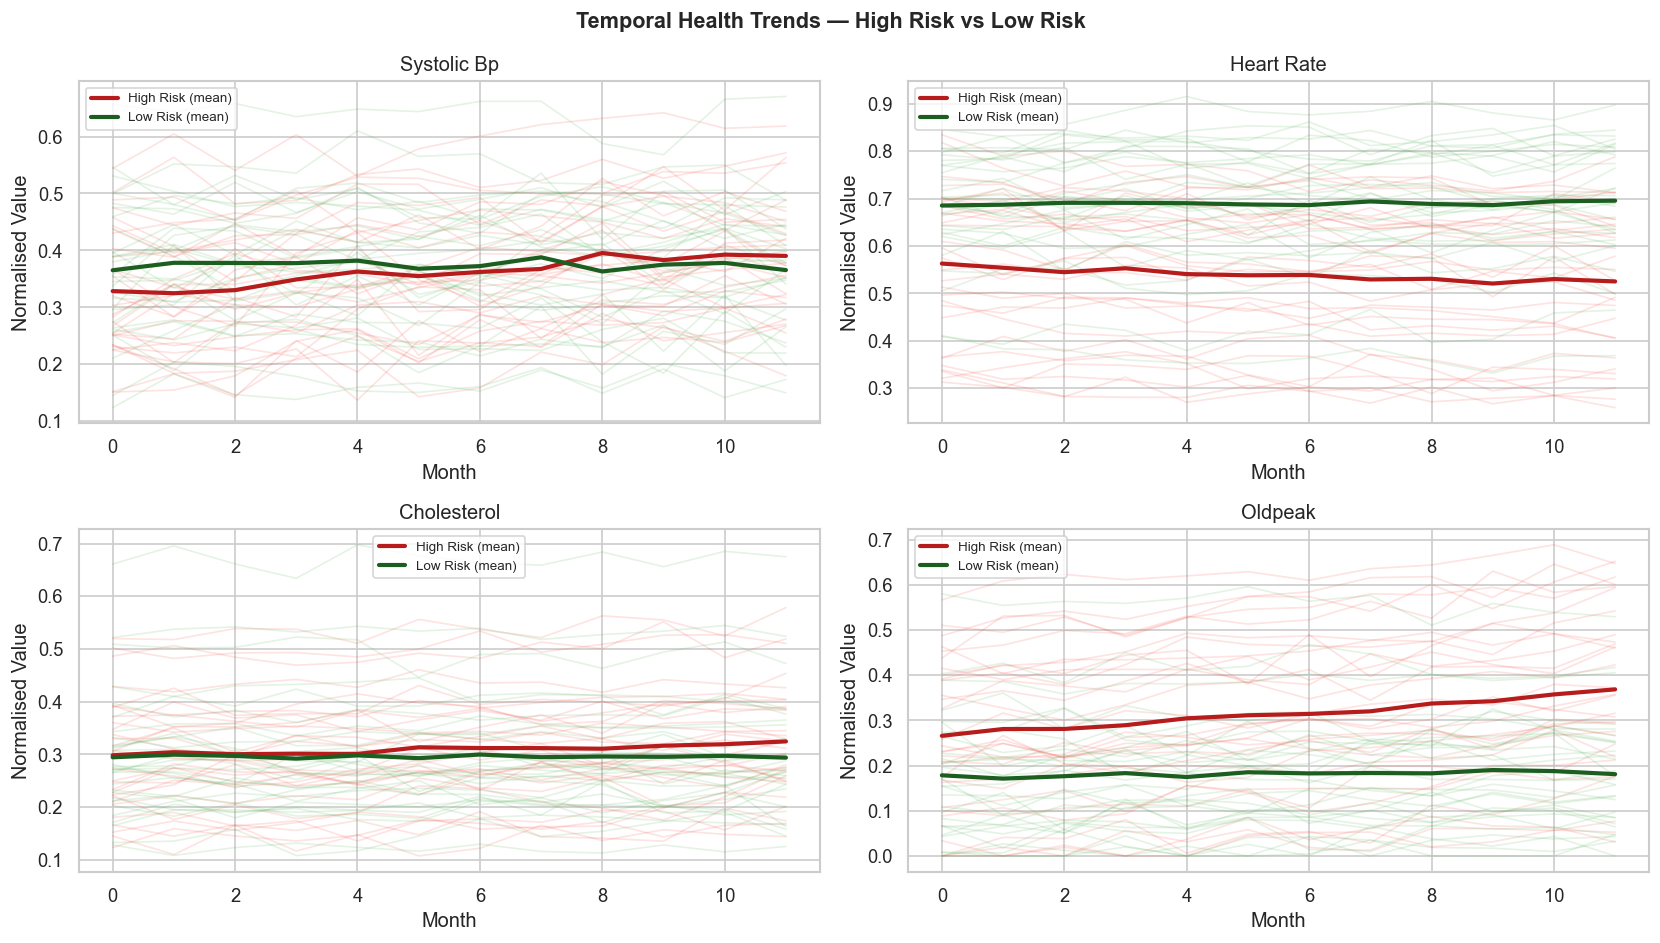

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

high_risk_idx = np.where(labels == 1)[0][:30]
low_risk_idx  = np.where(labels == 0)[0][:30]
timesteps     = np.arange(sequences.shape[1])

for f, (feat, ax) in enumerate(zip(TEMPORAL_FEATURES, axes)):
    for idx in high_risk_idx:
        ax.plot(timesteps, sequences[idx, :, f], color='#F44336', alpha=0.15, lw=1)
    for idx in low_risk_idx:
        ax.plot(timesteps, sequences[idx, :, f], color='#4CAF50', alpha=0.15, lw=1)

    # Mean trends
    ax.plot(timesteps, sequences[high_risk_idx, :, f].mean(axis=0),
            color='#B71C1C', lw=2.5, label='High Risk (mean)')
    ax.plot(timesteps, sequences[low_risk_idx,  :, f].mean(axis=0),
            color='#1B5E20', lw=2.5, label='Low Risk (mean)')

    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Month')
    ax.set_ylabel('Normalised Value')
    ax.legend(fontsize=8)

plt.suptitle('Temporal Health Trends — High Risk vs Low Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    sequences, labels, test_size=0.2, random_state=RANDOM_STATE, stratify=labels
)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')
print(f'Train balance — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}')
print(f'Val   balance — 0: {(y_val==0).sum()}    1: {(y_val==1).sum()}')

Train: (237, 12, 4)  |  Val: (60, 12, 4)
Train balance — 0: 128  1: 109
Val   balance — 0: 32    1: 28


## 5. Train LSTM

In [6]:
full_model, encoder_model, history = train(
    X_train, y_train, X_val, y_val,
    epochs=100,
    batch_size=32,
    learning_rate=0.001,
    log_mlflow=True,
)

print('\n── Validation Metrics ──')
print(f'  Accuracy : {history["val_accuracy"][-1]:.4f}')
print(f'  Recall   : {history["val_recall"][-1]:.4f}')
print(f'  AUC      : {history["val_auc"][-1]:.4f}')

2026/05/22 21:50:13 INFO mlflow.tracking.fluent: Experiment with name 'CardioScope-XAI / LSTM' does not exist. Creating a new experiment.


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.6245 - auc: 0.6815 - loss: 0.7397 - recall: 0.3028 - val_accuracy: 0.8000 - val_auc: 0.9018 - val_loss: 0.6578 - val_recall: 0.6786 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7342 - auc: 0.7857 - loss: 0.7085 - recall: 0.5138 - val_accuracy: 0.8167 - val_auc: 0.8940 - val_loss: 0.6058 - val_recall: 0.7143 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7257 - auc: 0.7871 - loss: 0.6701 - recall: 0.5321 - val_accuracy: 0.8500 - val_auc: 0.8895 - val_loss: 0.5438 - val_recall: 0.8571 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7300 - auc: 0.7911 - loss: 0.6283 - recall: 0.6147 - val_accuracy: 0.8000 - val_auc: 0.8795 - val_loss: 0.4883 - val_recall: 0.8571 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7131 - auc: 0.8123 - loss: 0.5810 - recall: 0.6972 - va

## 6. Training Curves

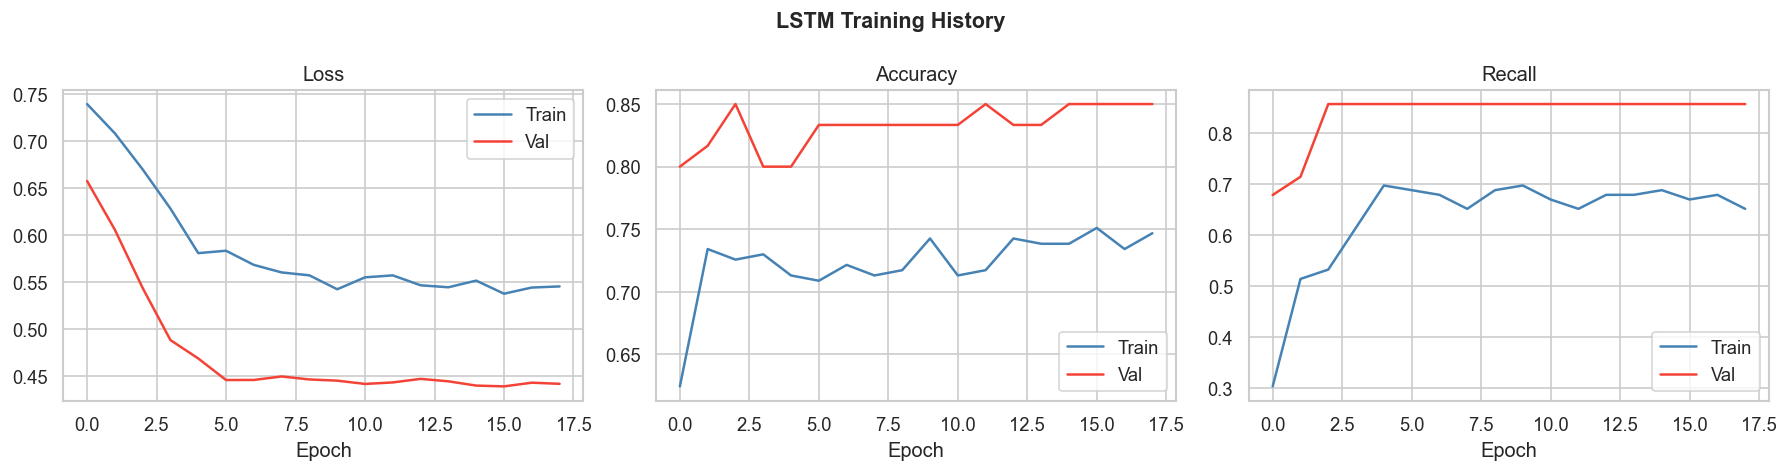

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_to_plot = [
    ('loss',     'val_loss',     'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('recall',   'val_recall',   'Recall'),
]

for ax, (train_key, val_key, title) in zip(axes, metrics_to_plot):
    ax.plot(history[train_key], label='Train', color='steelblue')
    ax.plot(history[val_key],   label='Val',   color='#F44336')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('LSTM Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Extract Temporal Embeddings

In [8]:
embeddings = extract_embeddings(encoder_model, sequences)
print(f'Temporal embeddings shape: {embeddings.shape}')  # (n_patients, 16)

# Save embeddings for fusion notebook
import numpy as np
np.save('../data/temporal/lstm_embeddings.npy', embeddings)
print('Saved → data/temporal/lstm_embeddings.npy')

Temporal embeddings shape: (297, 16)
Saved → data/temporal/lstm_embeddings.npy


## 8. Embedding Space Visualisation (PCA)

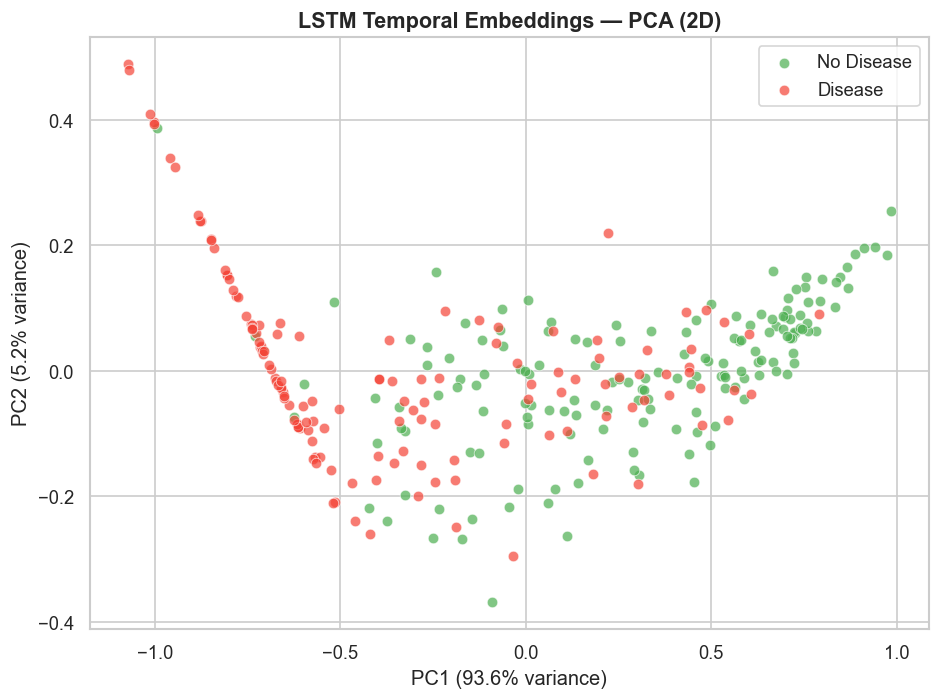

In [9]:
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=RANDOM_STATE)
emb2d = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, '#4CAF50', 'No Disease'), (1, '#F44336', 'Disease')]:
    mask = labels == label
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1],
               c=color, label=name, alpha=0.7, s=40, edgecolors='white', lw=0.5)

ax.set_title('LSTM Temporal Embeddings — PCA (2D)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Item | Detail |
|---|---|
| Input shape | (n_patients, 12, 4) |
| Features | Systolic BP, Heart Rate, Cholesterol, ST Depression |
| Architecture | LSTM(64) → LSTM(32) → Dense(16) → Dense(1) |
| Embedding dim | 16 (used in fusion layer) |
| Saved | `models/lstm_model.keras`, `models/lstm_encoder.keras` |
| Embeddings | `data/temporal/lstm_embeddings.npy` |